# COMP4318/5318 Assignment 2: Image Classification

#### Group number: 100
##### SID1: 530839244
##### SID2: 540958494
##### SID3: 550120560
##### SID4: 550053316

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment. 

In [21]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

#------------------------------------#
Context:
#------------------------------------#
This dataset (PathMNIST) contains images of colorectal cancer histology slides containing 9 types of tissues:
  Class 0: Adipose
  Class 1: Background
  Class 2: Debris
  Class 3: Lymphocytes
  Class 4: Mucus
  Class 5: Smooth Muscle
  Class 6: Normal Colon Mucosa
  Class 7: Cancer-associated Stroma
  Class 8: Colorectal Adenocarcinoma

#------------------------------------#
Class Shapes & Data Type:
#------------------------------------#
Shape of X_train: (32000, 28, 28, 3)
Hence there are 32000 28x28 photos with 3 colour channels in the training dataset

Shape of y_train: (32000,)
Hence there are 32000 labels in the training dataset

Shape of X_test: (8000, 28, 28, 3)
Hence there are 32000 28x28 photos with 3 colour channels in the test dataset

Shape of y_test: (8000,)
Hence there are 8000 labels in the test dataset

The pixels in each image are of type: uint8

#-----------------------------------

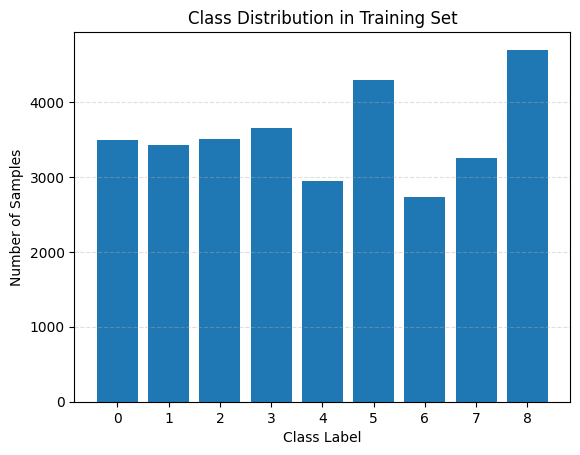

Hence it is clear the distribution between classes is relatively even and does not require re-weighting

#------------------------------------#
Example Pictures:
#------------------------------------#


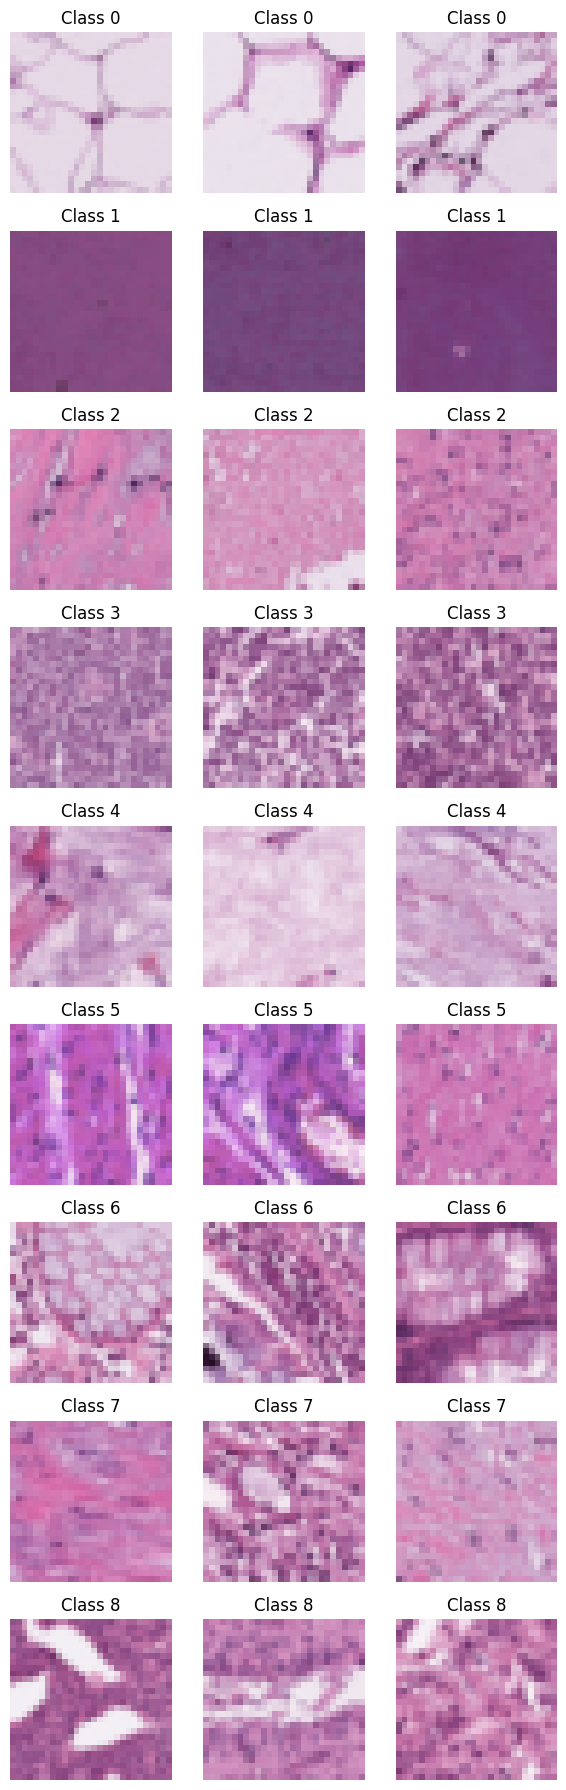

#------------------------------------#
Pixel Intensity Analysis:
#------------------------------------#
Red - Mean: 188.65, Std: 31.91
Green - Mean: 135.93, Std: 45.60
Blue - Mean: 180.05, Std: 32.18


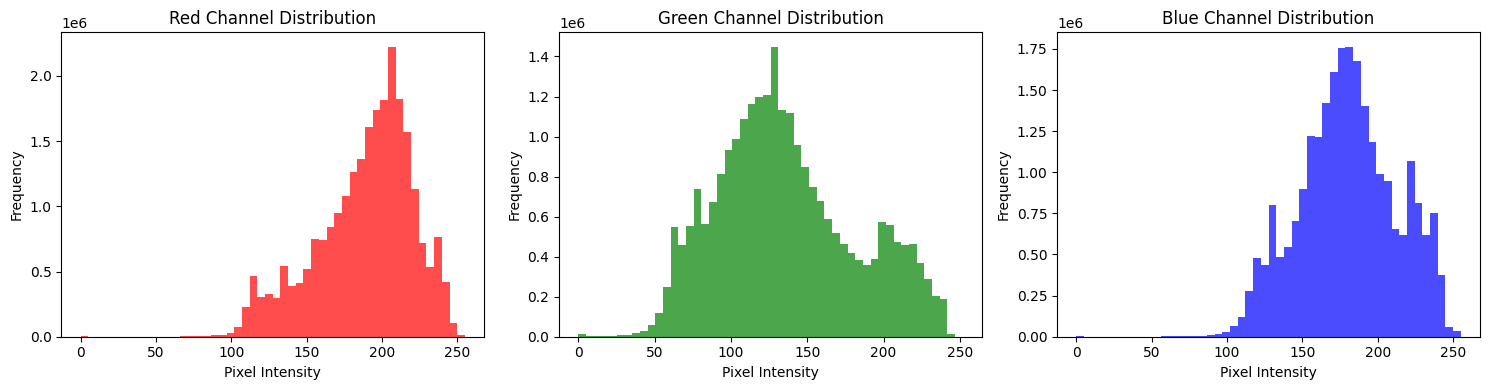


Pixel values range from 0-255, confirming normalisation is required
#------------------------------------#
Pre-processing:
#------------------------------------#
Normalised pixel range: [0.0, 1.0]
Normalisation maps pixel values from [0,255] to [0,1].
This ensures stable gradients during backpropagation and prevents
any single channel dominating due to scale.

Flattened shape for classical ML: (32000, 2352)
Flattening converts 2D image structure into a 1D feature vector
required as input for SVM and other classical algorithms.



In [54]:
# Load the dataset training and test sets as numpy arrays
X_train = np.load('Data/X_train.npy')
y_train = np.load('Data/y_train.npy')
X_test = np.load('Data/X_test.npy')
y_test = np.load('Data/y_test.npy')

print("#------------------------------------#")
print("Context:")
print("#------------------------------------#")
print("This dataset (PathMNIST) contains images of " 
"colorectal cancer histology slides containing 9 types of tissues:")

# PathMNIST class labels
class_names = {
    0: 'Adipose',
    1: 'Background',
    2: 'Debris',
    3: 'Lymphocytes',
    4: 'Mucus',
    5: 'Smooth Muscle',
    6: 'Normal Colon Mucosa',
    7: 'Cancer-associated Stroma',
    8: 'Colorectal Adenocarcinoma'
}

for k, v in class_names.items():
    print(f"  Class {k}: {v}")


# Print shapes
print("\n#------------------------------------#")
print("Class Shapes & Data Type:")
print("#------------------------------------#")
print(f"Shape of X_train: {np.shape(X_train)}")
print("Hence there are 32000 28x28 photos with 3 colour channels in the training dataset\n")

print(f"Shape of y_train: {np.shape(y_train)}")
print("Hence there are 32000 labels in the training dataset\n")

print(f"Shape of X_test: {np.shape(X_test)}")
print("Hence there are 32000 28x28 photos with 3 colour channels in the test dataset\n")

print(f"Shape of y_test: {np.shape(y_test)}")
print("Hence there are 8000 labels in the test dataset\n")

print(f"The pixels in each image are of type: {X_test.dtype}\n")



# Print class counts
print("#------------------------------------#")
print("Class distributions:")
print("#------------------------------------#")
unique, counts = np.unique(y_train, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

plt.bar(unique, counts)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.xticks(unique)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

print("Hence it is clear the distribution between classes is relatively even and does not require re-weighting\n")



# Dispay sample images from different classes 
print("#------------------------------------#")
print("Example Pictures:")
print("#------------------------------------#")

classes = np.unique(y_train)
num_classes = len(classes)

# Create plot with 3 images for each clas
fig, axes = plt.subplots(num_classes, 3, figsize=(6, 2 * num_classes))

for i, cls in enumerate(classes):
    # Find indexes for all images in each class
    idxs = np.where(y_train == cls)[0]
    
    # Pick 3 random images from each class
    selected = np.random.choice(idxs, 3, replace=False)
    
    for j in range(3):
        ax = axes[i, j] if num_classes > 1 else axes[j]
        ax.imshow(X_train[selected[j]])
        ax.set_title(f"Class {cls}")
        ax.axis('off')

plt.tight_layout()
plt.show()


# Mean pixel intensity per channel across dataset
print("#------------------------------------#")
print("Pixel Intensity Analysis:")
print("#------------------------------------#")

channel_names = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for c in range(3):
    channel_data = X_train[:, :, :, c].flatten()
    axes[c].hist(channel_data, bins=50, color=colors[c], alpha=0.7)
    axes[c].set_title(f'{channel_names[c]} Channel Distribution')
    axes[c].set_xlabel('Pixel Intensity')
    axes[c].set_ylabel('Frequency')
    print(f"{channel_names[c]} - Mean: {channel_data.mean():.2f}, Std: {channel_data.std():.2f}")

plt.tight_layout()
plt.show()

print("\nPixel values range from 0-255, confirming normalisation is required")




print("#------------------------------------#")
print("Pre-processing:")
print("#------------------------------------#")

# For CNN and MLP input
# Normalise pixel values to [0, 1] for neural networks
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print(f"Normalised pixel range: [{X_train_norm.min()}, {X_train_norm.max()}]")
print("Normalisation maps pixel values from [0,255] to [0,1].")
print("This ensures stable gradients during backpropagation and prevents")
print("any single channel dominating due to scale.\n")

# For SVM (and other classical models)
# Flatten images from (N, 28, 28, 3) to (N, 2352)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"Flattened shape for classical ML: {X_train_flat.shape}")
print("Flattening converts 2D image structure into a 1D feature vector")
print("required as input for SVM and other classical algorithms.\n")




### Examples of preprocessed data
Please print/display some examples of your preprocessed data here.

## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course
- I think SVM or random forrest with dimensionality reduction could work best? i assume it'll all perform horribly though

### Fully connected neural network

### Convolutional neural network

## 3. Hyperparameter tuning

### Algorithm of choice from first six weeks of course

### Fully connected neural network

### Convolutional neural network

## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### Algorithm of choice from first six weeks of course

### Fully connected neural network

### Convolutional neural network

## 5. AI Acknowledgement
Include acknowledgement of AI usage here. 
